## Modelo Selecionado

Com base no recall obtido na validação, o **SGDClassifier** foi selecionado como o modelo final
para apoio ao diagnóstico de diabetes.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from train import train_models
from preprocessing import preprocess_data


In [8]:
results, models, (X_test, y_test) = train_models()

best_model = models["SGD Classifier"]

print("Using SGD Classifier as final model")



Model: Logistic Regression (GridSearch)
Accuracy: 0.7130
Precision: 0.5946
Recall: 0.5500
F1_score: 0.5714

Model: Decision Tree (RandomSearch)
Accuracy: 0.6957
Precision: 0.5610
Recall: 0.5750
F1_score: 0.5679

Model: SGD Classifier
Accuracy: 0.6696
Precision: 0.5208
Recall: 0.6250
F1_score: 0.5682
Using SGD Classifier as final model


c:\Users\lucc-\OneDrive\Documents\facul\gitHub\dIAbetes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [3]:
_, _, _, _, _, _, preprocessor = preprocess_data()
feature_names = preprocessor.get_feature_names_out()


In [9]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df


,feature,coefficient
1,num__Glucose,2.313000
0,num__Pregnancies,1.550802
6,num__DiabetesPedigreeFunction,1.170001
4,num__Insulin,0.712276
2,num__BloodPressure,-0.580823
7,num__Age,0.367981
5,num__BMI,0.362483
3,num__SkinThickness,-0.046428


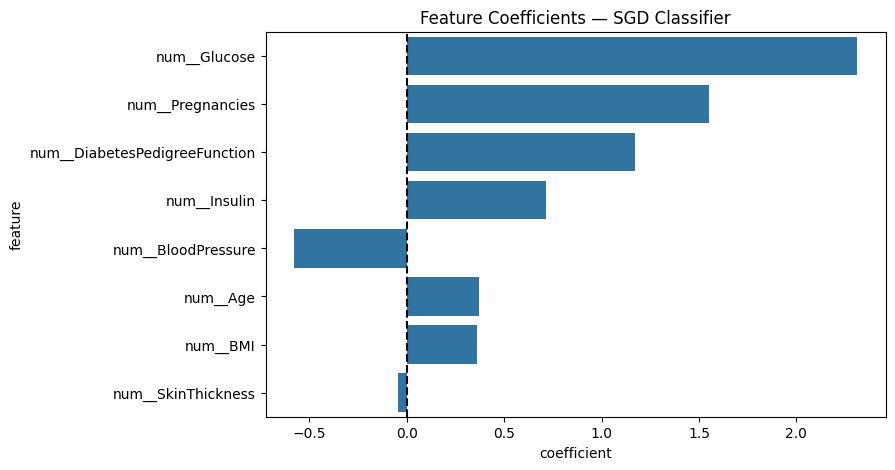

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_df,
    x="coefficient",
    y="feature"
)
plt.title("Feature Coefficients — SGD Classifier")
plt.axvline(0, color="black", linestyle="--")
plt.show()


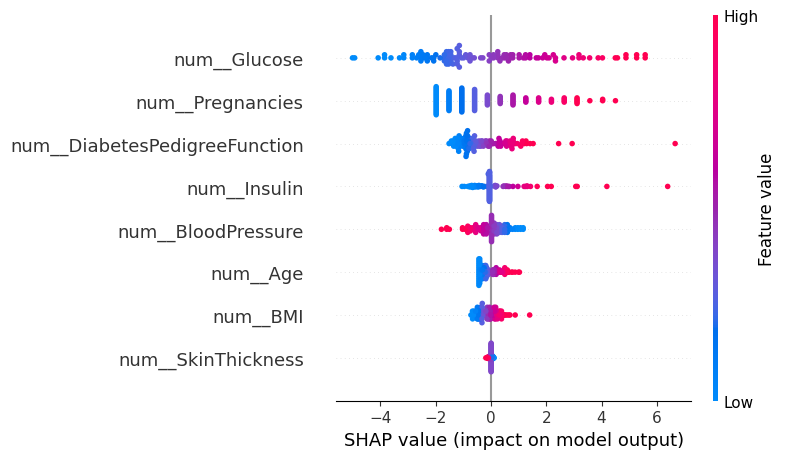

In [12]:
X_train, _, X_test, y_train, _, y_test, _ = preprocess_data()

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)


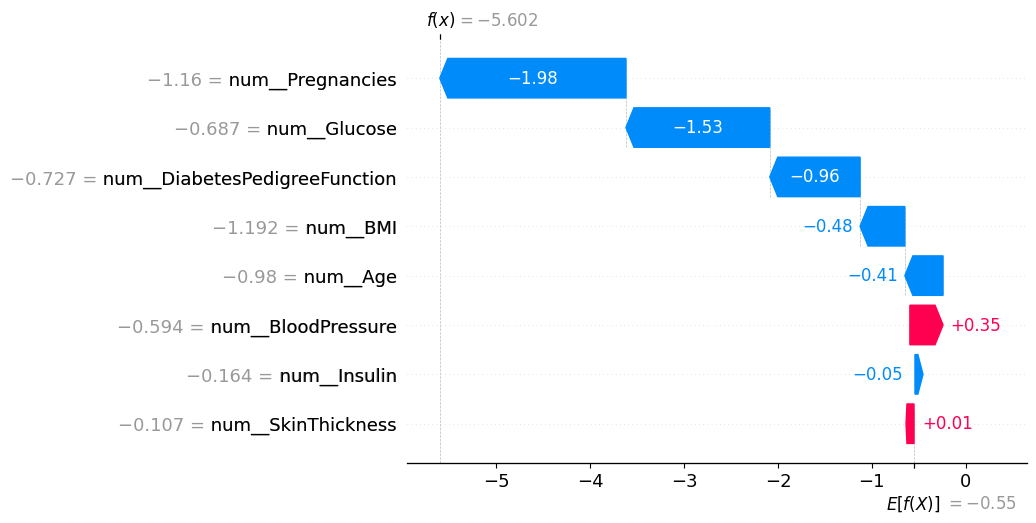

In [17]:
sample_idx = 0

shap.plots.waterfall(
    shap_values[sample_idx],
)


## Conclusões sobre a Interpretabilidade

A análise de interpretabilidade confirma que o nível de glicose é a
característica mais importante que influencia a predição de diabetes,
seguida pelo IMC (Índice de Massa Corporal) e pela idade.  
Tanto a análise dos coeficientes quanto as explicações por meio do SHAP
são consistentes com o conhecimento clínico, reforçando a confiabilidade
do modelo.
